# Data Engineering Capstone Project

**Goal**: In this project, we will implement ETL pipeline with TPC-H dataset to help the Supply Chain department to keep track of the number of shipping days of their orders and identify spaces for improvements.

The data is available in a duckdb database. See the data model below:

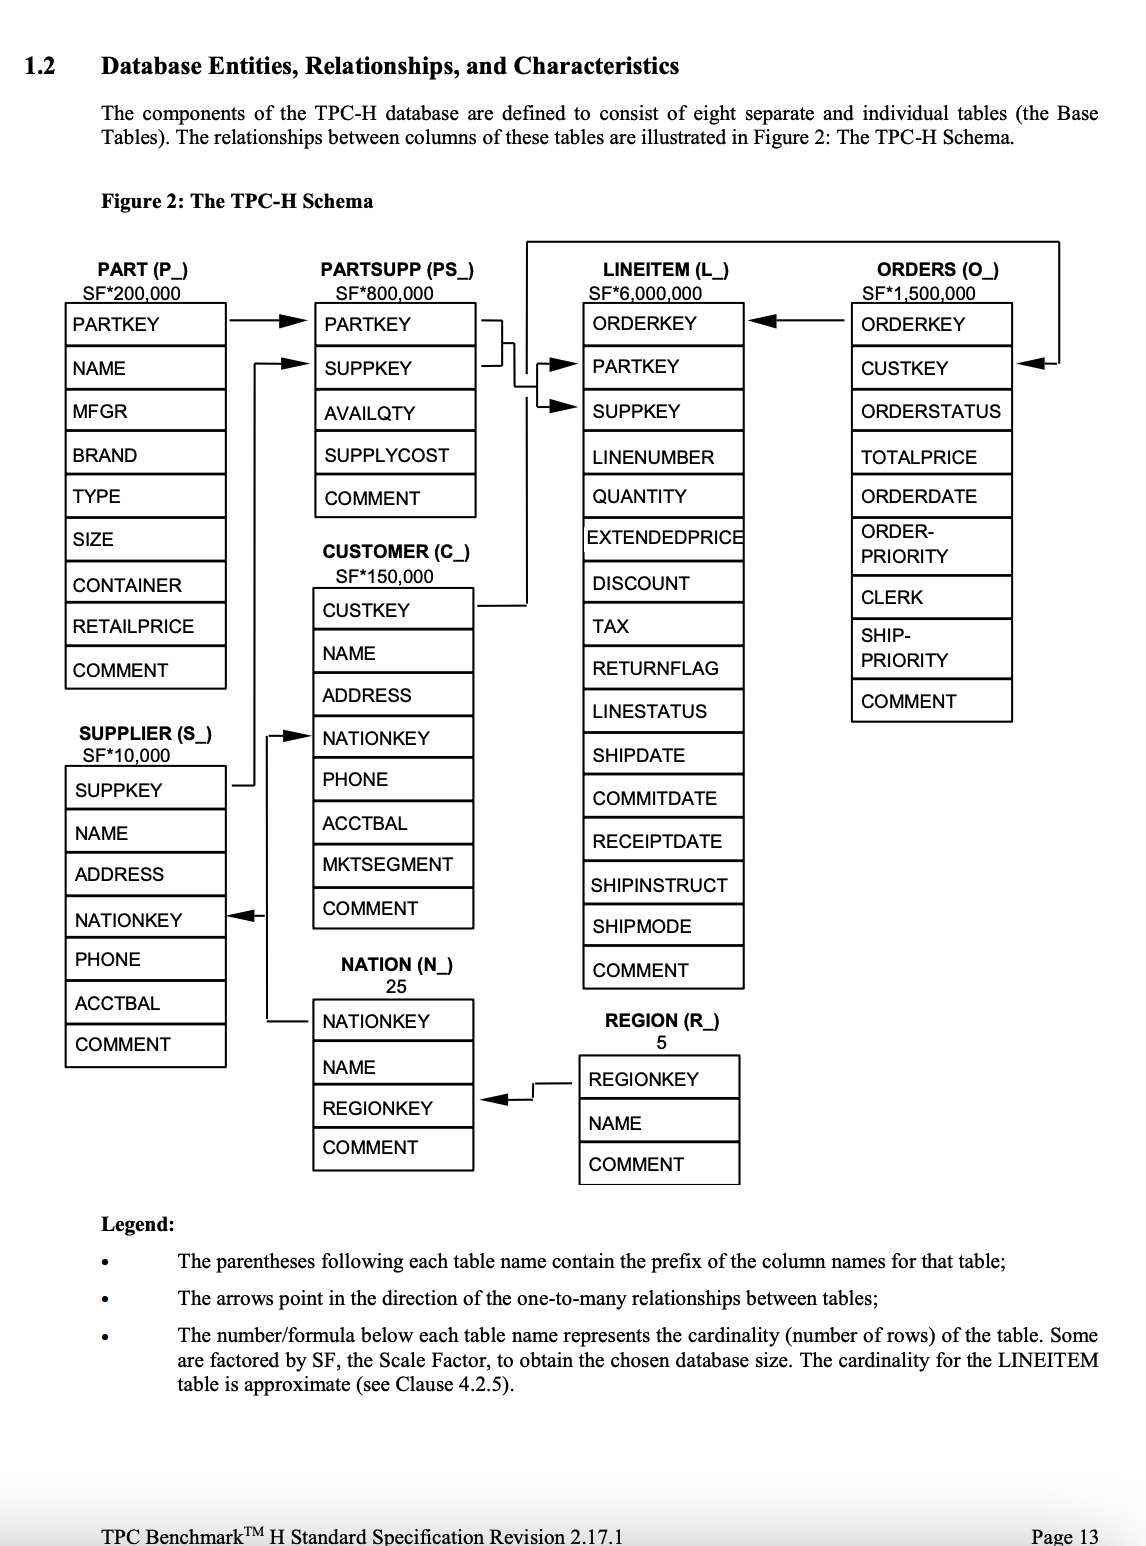

In [1]:
import duckdb
import os
import polars as pl
import sqlite3

## ETL

To create reports of shipping date by supplier, by nation, and by shipping mode, we will need 4 tables from the dataset. Then, following join tables will be needed. We will implement the 3-hop architecture (bronze, silver, and gold) as follow.

In [2]:
# Load 100MB TPCH data from duckdb.
! python ./setup/build_connection.py

Cleaning up tpch and metadata db files
Creating TPCH input data
Creating metadata table


### Bronze layer
In this layer, we will load datasets as they are from the database.

In [3]:
con = duckdb.connect("tpch.db")
lineitem_df = con.sql("select * from lineitem").pl().rename(lambda colname: colname[2:])
nation_df = con.sql("select * from nation").pl().rename(lambda colname: colname[2:])
orders_df = con.sql("select * from orders").pl().rename(lambda colname: colname[2:])
supplier_df = con.sql("select * from supplier").pl().rename(lambda colname: colname[2:])

con.close()

### Silver layer
In this step, we will model data for analytics. We will use Kimball's dimensional model, as it is the most commonly used one and can account for many use cases.

We will create the following dataset:
1. `dim_supplier`: A supplier table with all the necessary attributes of a supplier. We will join nation data to the `supplier_df`
2. `fct_lineitem`: An lineitem (items that are part of an order) fact table. This table will be the same as `lineitem_df` since the `lineitem` table has all the lineitem level details and keys to associate with dimension tables like `partkey` and `suppkey`.
3. `fct_orders`: An order level fact (an event that happened) table. This will be the same as `orders_df` since the orders table has all the necessary details about the order and how it associates with dimension tables like `customer_key`.
4. `fct_shipping`: A lineitem fact table with all the necessary attributes to the line item and its shipping date joined from `order_df`

In [4]:
dim_supplier = supplier_df\
    .join(nation_df, on="nationkey", how="left", suffix="_nation")\
    .rename({
        "name_nation": "nation_name",
        "comment_nation": "nation_comment"
    })

fct_orders = orders_df
fct_lineitem = lineitem_df
fct_shipping = lineitem_df\
    .join(orders_df, on="orderkey", how="inner", suffix="_order")\
    .rename(
        {
            "comment_order" : "order_comment"
        }
    )

### Gold layer
The gold layer contains datasets required for the end user. The user-required datasets are fact tables joined with dimension tables aggregated to the necessary grain. We will create both OBT and pre-aggregated tables.

#### OBT: Join the fact table with all its dimensions

In [5]:
wide_supplier = fct_shipping\
    .join(dim_supplier, on="suppkey", how="left", suffix="_supplier")\
    .rename(
        {
           "comment_supplier": "supplier_comment", 
           "name" : "supplier_name"
        }
    )

#### Pre-aggregated tables: Aggregate OBTs to stakeholder-specific grain
We will create 3 tables that summarize (min, max, avg) the shipping days by supplier, shipping mode, and nation

In [6]:
wide_shipping_length = wide_supplier.with_columns(
    (pl.col("shipdate") - pl.col("orderdate")).dt.total_days().alias("shipping_length")
)

In [7]:
def summarize(dimension):
    column_name = f"agg_{dimension}"
    column_name = wide_shipping_length.group_by(dimension).agg([
        pl.col("shipping_length").max().alias("max_days"),
        pl.col("shipping_length").min().alias("min_days"),
        pl.col("shipping_length").mean().alias("avg_days")
    ]).sort("avg_days")
    return column_name

In [8]:
summarize("supplier_name")
summarize("shipmode")
summarize("nation_name")

nation_name,max_days,min_days,avg_days
str,i64,i64,f64
"""UNITED KINGDOM""",121,1,59.398021
"""MOROCCO""",121,1,59.96577
"""ROMANIA""",121,1,59.966758
"""PERU""",121,1,60.165021
"""IRAQ""",121,1,60.364455
…,…,…,…
"""BRAZIL""",121,1,62.104453
"""SAUDI ARABIA""",121,1,62.796748
"""JORDAN""",121,1,62.798995


## Orchestration and scheduling
We will run `Apache Airflow` to schedule and orchestrate our pipeline. We will set the schedule to be every 1 min (so that we can check them quickly) and we only have to run this function which runs the ETL and outputs the `supply_chain_shipping_metrics` data.

## Visualization
We will generate HTML dashboard for the Supply Chain department.